# Notebook 12 — Statistical Inference for Outside-Shot Chain Value

This notebook quantifies uncertainty around the main findings from the context-stratified outside-shot analysis.

The analysis asks four targeted questions:

1. Within each offensive context, is the chain-goal-rate difference from one to two observed attacking skaters in the slot distinguishable from zero?
2. Is the one-to-two support increase larger than the zero-to-one increase?
3. In settled offensive-zone play, is the chain-goal-rate difference from two to three-or-more observed slot attackers distinguishable from zero?
4. How do the unadjusted confidence-interval results align with the previously completed controlled analysis?

The notebook emphasizes effect sizes, uncertainty intervals, and robustness rather than predictive model performance.

All findings are observational. Observed slot support is not randomly assigned, so estimates should not be interpreted as causal effects.

## 1. Setup

In [1]:
# Import packages and define project paths

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
INPUT_PATH = DATA_PROCESSED / "origin_shot_sequences_context_labeled.parquet"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Input exists: {INPUT_PATH.exists()}")
print(f"Input path: {INPUT_PATH}")

Project root: C:\Users\rinal\hockey-analytics\outside-shot-value
Input exists: True
Input path: C:\Users\rinal\hockey-analytics\outside-shot-value\data\processed\origin_shot_sequences_context_labeled.parquet


## 2. Load and Validate the Analysis Dataset

Load the context-labeled origin-shot sequence dataset produced by the upstream pipeline.

This notebook uses one row per origin-shot chain. Validation checks confirm that the fields required to reconstruct the established analysis cohort and conduct the statistical comparisons are present.

In [2]:
# Load the context-labeled origin-shot sequence dataset

origin_chains = pd.read_parquet(INPUT_PATH)

print(f"Rows: {len(origin_chains):,}")
print(f"Columns: {origin_chains.shape[1]:,}")
print(f"Unique chain IDs: {origin_chains['chain_id'].nunique():,}")

origin_chains.head()

Rows: 48,673
Columns: 111
Unique chain IDs: 48,673


,chain_id,game_id,period,sequence_id,team_id,raw_first_chance_team_id,n_team_id_overrides_for_chain,chain_start_time,chain_end_time,chain_duration_seconds,n_chances_in_chain,anchor_origin_event_id,anchor_origin_period_time,anchor_origin_location,anchor_first_chance_event_id,anchor_first_chance_time,anchor_first_event_type,anchor_first_chance_location,first_evaluated_chance_event_id,first_evaluated_chance_time,first_evaluated_event_type,first_evaluated_location,first_evaluated_xg,chain_max_xg,chain_sum_xg,has_deflection,n_deflections,first_deflection_event_id,first_deflection_time,deflection_max_xg,deflection_sum_xg,has_followup_chance,n_followup_chances,first_followup_event_id,first_followup_time,followup_max_xg,followup_sum_xg,chain_goal,chain_goal_event_id,chain_goal_time,chain_goal_player_id,chain_goal_player_name,chain_any_goal_within_2s_flag,origin_tracking_rows,origin_identified_tracking_players,origin_missing_tracking_player_rows,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,...,game_stint,period_time_end,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,origin_time_within_stint,is_5v5,team_n_skaters,opponent_n_skaters,team_net_empty,opponent_net_empty,raw_anchor_origin_period_time,anchor_origin_event_type_raw,anchor_origin_event_team,anchor_origin_x_adj,anchor_origin_y_adj,is_offensive_zone_origin,is_behind_offensive_blue_line_origin,chain_team_name,prior_faceoff_event_id,prior_faceoff_time,prior_faceoff_team,prior_faceoff_x_adj_for_event_team,prior_faceoff_y_adj_for_event_team,seconds_since_prior_faceoff,prior_faceoff_x_adj_for_chain_team,prior_faceoff_y_adj_for_chain_team,has_prior_faceoff_in_sequence,prior_faceoff_within_5s,prior_faceoff_in_offensive_zone_for_chain,oz_faceoff_context_5s,first_same_team_event_time_in_sequence,n_same_team_events_in_sequence,seconds_since_first_same_team_event_in_sequence,early_same_team_sequence_5s_diagnostic,settled_sequence_gt5s_diagnostic,entry_proxy_event_id,entry_proxy_time,entry_proxy_event_type,entry_proxy_x_adj_for_chain_team,entry_proxy_y_adj_for_chain_team,seconds_since_entry_proxy,has_entry_proxy_in_sequence,entry_proxy_within_5s,oz_entry_context_5s_proxy,settled_offensive_zone_context_proxy,shot_context
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s11_td...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,11,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,0,591.730000,591.730000,0.000000,1,565,591.730000,outside,565,591.730000,shot,outside,565,591.730000,shot,outside,0.040997,0.040997,0.040997,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,8,7,1,4,3,1,2,...,64.000000,605.030000,4.000000,4.000000,False,False,1.000000,1.000000,True,False,4.000000,4.000000,False,False,591.730000000,shot,CLE,32.889107,25.397057,True,False,CLE,558.000000,589.030000,CLE,69.104380,21.376137,2.700000,69.104380,21.376137,True,True,True,True,589.030000,20,2.700000,True,False,560.000000,589.100000,pass,69.100876,23.385292,2.630000,True,True,True,False,oz_faceoff_5s
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,722.400000,722.400000,0.000000,1,687,722.400000,outside,687,722.400000,shot,outside,687,722.400000,shot,outside,0.015540,0.015540,0.015540,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,10,7,3,4,3,1,2,...,80.000000,725.030000,5.000000,5.000000,False,False,1.000000,1.000000,True,True,5.000000,5.000000,False,False,722.400000000,shot,GR,52.107956,-8.799999,True,False,GR,589.000000,620.030000,CLE,-19.413269,20.873200,102.370000,19.413269,-20.873200,True,False,False,False,620.030000,89,102.370000,False,True,598.000000,637.530000,carry,25.955010,-36.461760,84.870000,True,False,False,True,settled_offensive_zone_proxy
2,00b0366a-95c6-5250-2dae-

In [3]:
# Validate the columns required for cohort construction and statistical inference

required_columns = [
    "chain_id",
    "game_id",
    "period",
    "team_id",
    "is_5v5",
    "anchor_origin_location",
    "is_offensive_zone_origin",
    "is_behind_offensive_blue_line_origin",
    "anchor_origin_x_adj",
    "anchor_origin_y_adj",
    "shot_context",
    "first_evaluated_xg",
    "chain_goal",
    "origin_tracking_available",
    "origin_tracking_error_flag",
    "origin_tracking_completeness_bucket",
    "observed_origin_attackers_in_slot",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
]

missing_required_columns = sorted(
    set(required_columns) - set(origin_chains.columns)
)

dataset_validation = {
    "rows": len(origin_chains),
    "columns": origin_chains.shape[1],
    "unique_chain_ids": origin_chains["chain_id"].nunique(),
    "duplicate_chain_ids": int(origin_chains["chain_id"].duplicated().sum()),
    "missing_required_columns": missing_required_columns,
}

dataset_validation

{'rows': 48673,
 'columns': 111,
 'unique_chain_ids': 48673,
 'duplicate_chain_ids': 0,
 'missing_required_columns': []}

In [4]:
# Enforce the upstream dataset requirements before analysis

assert dataset_validation["rows"] > 0
assert dataset_validation["duplicate_chain_ids"] == 0
assert not dataset_validation["missing_required_columns"]

print("Dataset validation passed.")

Dataset validation passed.


## 3. Reconstruct the Clean Analysis Cohort

Reconstruct the same clean cohort used in the context-stratified and chain-value analyses.

The cohort is limited sequentially to:

1. true 5v5 origin-shot chains;
2. outside-shot origins;
3. offensive-zone origins;
4. chains with usable origin tracking;
5. origins not recorded behind the offensive blue line.

The final geometric condition is retained as a validation safeguard, although it removes no additional chains from the current processed dataset.

Tracking completeness is not treated as strength state. True 5v5 status was assigned upstream from the stint data.

In [5]:
# Define the sequential cohort conditions

all_origin_chains_mask = pd.Series(
    True,
    index=origin_chains.index,
)

is_5v5_mask = (
    all_origin_chains_mask
    & origin_chains["is_5v5"].fillna(False)
)

outside_origin_mask = (
    is_5v5_mask
    & origin_chains["anchor_origin_location"].eq("outside")
)

offensive_zone_mask = (
    outside_origin_mask
    & origin_chains["is_offensive_zone_origin"].fillna(False)
)

tracking_usable_mask = (
    offensive_zone_mask
    & origin_chains["origin_tracking_available"].fillna(False)
    & ~origin_chains["origin_tracking_error_flag"].fillna(True)
)

clean_analysis_mask = (
    tracking_usable_mask
    & ~origin_chains[
        "is_behind_offensive_blue_line_origin"
    ].fillna(True)
)

In [6]:
# Build a cohort waterfall to verify that the established sample is reproduced

cohort_steps = [
    ("all_origin_shot_chains", all_origin_chains_mask),
    ("is_5v5", is_5v5_mask),
    ("is_5v5_outside_origin", outside_origin_mask),
    (
        "is_5v5_outside_origin_offensive_zone",
        offensive_zone_mask,
    ),
    (
        "is_5v5_outside_origin_offensive_zone_tracking_usable",
        tracking_usable_mask,
    ),
    (
        "clean_analysis_cohort",
        clean_analysis_mask,
    ),
]

cohort_waterfall_rows = []
previous_count = len(origin_chains)

for cohort_name, cohort_mask in cohort_steps:
    cohort_count = int(cohort_mask.sum())

    cohort_waterfall_rows.append(
        {
            "cohort": cohort_name,
            "chains": cohort_count,
            "pct_of_all": cohort_count / len(origin_chains),
            "pct_of_previous": cohort_count / previous_count,
        }
    )

    previous_count = cohort_count

cohort_waterfall = pd.DataFrame(cohort_waterfall_rows)

cohort_waterfall

,cohort,chains,pct_of_all,pct_of_previous
0,all_origin_shot_chains,48673,1.000000,1.000000
1,is_5v5,36357,0.746964,0.746964
2,is_5v5_outside_origin,23754,0.488032,0.653354
3,is_5v5_outside_origin_offensive_zone,22919,0.470877,0.964848
4,is_5v5_outside_origin_offensive_zone_tracking_...,21536,0.442463,0.939657
5,clean_analysis_cohort,21536,0.442463,1.000000


In [7]:
# Materialize the clean analysis cohort

cohort = (
    origin_chains
    .loc[clean_analysis_mask]
    .copy()
    .reset_index(drop=True)
)

cohort_summary = {
    "rows": len(cohort),
    "unique_chain_ids": cohort["chain_id"].nunique(),
    "duplicate_chain_ids": int(cohort["chain_id"].duplicated().sum()),
    "unique_games": cohort["game_id"].nunique(),
    "chain_goals": int(cohort["chain_goal"].sum()),
    "chain_goal_rate": cohort["chain_goal"].mean(),
    "context_counts": cohort["shot_context"].value_counts().to_dict(),
}

cohort_summary

{'rows': 21536,
 'unique_chain_ids': 21536,
 'duplicate_chain_ids': 0,
 'unique_games': 476,
 'chain_goals': 537,
 'chain_goal_rate': np.float64(0.024934992570579496),
 'context_counts': {'settled_offensive_zone_proxy': 15387,
  'oz_entry_5s_proxy': 4020,
  'oz_faceoff_5s': 2115,
  'other_or_unknown': 14}}

In [8]:
# Validate that the established analysis cohort has been reproduced exactly

expected_context_counts = {
    "settled_offensive_zone_proxy": 15387,
    "oz_entry_5s_proxy": 4020,
    "oz_faceoff_5s": 2115,
    "other_or_unknown": 14,
}

assert len(cohort) == 21536
assert cohort["chain_id"].nunique() == 21536
assert cohort["chain_id"].duplicated().sum() == 0
assert int(cohort["chain_goal"].sum()) == 537
assert cohort["shot_context"].value_counts().to_dict() == expected_context_counts

print("Clean analysis cohort validation passed.")

Clean analysis cohort validation passed.


## 4. Define Slot-Support Groups and Statistical Contrasts

Observed attacking skaters in the slot are grouped as:

- `0`
- `1`
- `2`
- `3+`

The primary outcome is whether the chain produced a goal.

The statistical comparisons targeted in this notebook are:

1. `1 → 2`: goal-rate difference between two and one observed attacking skaters in the slot;
2. `0 → 1`: goal-rate difference between one and zero;
3. `2 → 3+`: goal-rate difference between three-or-more and two;
4. difference-in-differences: whether the `1 → 2` increase is larger than the `0 → 1` increase.

All contrasts are estimated separately by offensive context where sample size permits.

In [9]:
# Create ordered slot-support groups

cohort["attackers_slot_group"] = pd.cut(
    cohort["observed_origin_attackers_in_slot"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"],
    ordered=True,
)

slot_group_validation = {
    "rows": len(cohort),
    "missing_slot_groups": int(
        cohort["attackers_slot_group"].isna().sum()
    ),
    "raw_slot_counts": (
        cohort["observed_origin_attackers_in_slot"]
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "grouped_slot_counts": (
        cohort["attackers_slot_group"]
        .value_counts(sort=False)
        .to_dict()
    ),
}

slot_group_validation

{'rows': 21536,
 'missing_slot_groups': 0,
 'raw_slot_counts': {np.int64(0): 8280,
  np.int64(1): 8202,
  np.int64(2): 4427,
  np.int64(3): 618,
  np.int64(4): 9},
 'grouped_slot_counts': {'0': 8280, '1': 8202, '2': 4427, '3+': 627}}

In [10]:
# Define the analysis contexts and targeted statistical contrasts

analysis_contexts = [
    "settled_offensive_zone_proxy",
    "oz_entry_5s_proxy",
    "oz_faceoff_5s",
]

contrast_definitions = pd.DataFrame(
    [
        {
            "contrast": "0_to_1",
            "reference_group": "0",
            "comparison_group": "1",
            "estimand": "goal_rate_1_minus_goal_rate_0",
        },
        {
            "contrast": "1_to_2",
            "reference_group": "1",
            "comparison_group": "2",
            "estimand": "goal_rate_2_minus_goal_rate_1",
        },
        {
            "contrast": "2_to_3plus",
            "reference_group": "2",
            "comparison_group": "3+",
            "estimand": "goal_rate_3plus_minus_goal_rate_2",
        },
        {
            "contrast": "incremental_1_to_2_vs_0_to_1",
            "reference_group": None,
            "comparison_group": None,
            "estimand": (
                "(goal_rate_2_minus_goal_rate_1)"
                " - "
                "(goal_rate_1_minus_goal_rate_0)"
            ),
        },
    ]
)

contrast_definitions

,contrast,reference_group,comparison_group,estimand
0,0_to_1,0,1,goal_rate_1_minus_goal_rate_0
1,1_to_2,1,2,goal_rate_2_minus_goal_rate_1
2,2_to_3plus,2,3+,goal_rate_3plus_minus_goal_rate_2
3,incremental_1_to_2_vs_0_to_1,NaN,NaN,(goal_rate_2_minus_goal_rate_1) - (goal_rate_1...


In [11]:
# Validate slot-support grouping and the available analysis contexts

assert slot_group_validation["missing_slot_groups"] == 0
assert set(analysis_contexts).issubset(
    set(cohort["shot_context"].unique())
)
assert set(
    cohort["attackers_slot_group"].cat.categories
) == {"0", "1", "2", "3+"}

print("Slot-support groups and statistical contrasts validated.")

Slot-support groups and statistical contrasts validated.


## 5. Descriptive Effect Estimates

Before estimating uncertainty, summarize the observed chain-goal rates for each slot-support group within each offensive context.

These descriptive estimates establish the direction and magnitude of the patterns that the formal statistical comparisons will evaluate.

In [12]:
# Summarize chain-goal outcomes by context and slot-support group

descriptive_goal_rates = (
    cohort[
        cohort["shot_context"].isin(analysis_contexts)
    ]
    .groupby(
        ["shot_context", "attackers_slot_group"],
        observed=True,
    )
    .agg(
        chains=("chain_id", "count"),
        chain_goals=("chain_goal", "sum"),
        chain_goal_rate=("chain_goal", "mean"),
        mean_first_evaluated_xg=(
            "first_evaluated_xg",
            "mean",
        ),
    )
    .reset_index()
)

descriptive_goal_rates

,shot_context,attackers_slot_group,chains,chain_goals,chain_goal_rate,mean_first_evaluated_xg
0,oz_entry_5s_proxy,0,1927,36,0.018682,0.011902
1,oz_entry_5s_proxy,1,1398,35,0.025036,0.015328
2,oz_entry_5s_proxy,2,610,20,0.032787,0.019710
3,oz_entry_5s_proxy,3+,85,1,0.011765,0.024562
4,oz_faceoff_5s,0,431,9,0.020882,0.014024
5,oz_faceoff_5s,1,891,22,0.024691,0.016229
6,oz_faceoff_5s,2,672,19,0.028274,0.016571
7,oz_faceoff_5s,3+,121,6,0.049587,0.017366
8,settled_offensive_zone_proxy,0,5909,114,0.019293,0.012747
9,settled_offensive_zone_proxy,1,5912,155,0.026218,0.018588


In [13]:
# Create a compact context-by-support goal-rate table

goal_rate_pivot = (
    descriptive_goal_rates
    .pivot(
        index="shot_context",
        columns="attackers_slot_group",
        values="chain_goal_rate",
    )
    .reindex(index=analysis_contexts)
)

goal_rate_pivot

attackers_slot_group,0,1,2,3+
shot_context,,,,
settled_offensive_zone_proxy,0.019293,0.026218,0.034340,0.026128
oz_entry_5s_proxy,0.018682,0.025036,0.032787,0.011765
oz_faceoff_5s,0.020882,0.024691,0.028274,0.049587


In [14]:
# Calculate the pre-specified observed goal-rate contrasts by context

observed_contrast_rows = []

for context in analysis_contexts:
    context_rates = (
        descriptive_goal_rates.loc[
            descriptive_goal_rates["shot_context"].eq(context)
        ]
        .set_index("attackers_slot_group")["chain_goal_rate"]
    )

    required_groups = {"0", "1", "2", "3+"}

    if not required_groups.issubset(
        set(context_rates.index.astype(str))
    ):
        continue

    rate_0 = float(context_rates.loc["0"])
    rate_1 = float(context_rates.loc["1"])
    rate_2 = float(context_rates.loc["2"])
    rate_3plus = float(context_rates.loc["3+"])

    contrast_0_to_1 = rate_1 - rate_0
    contrast_1_to_2 = rate_2 - rate_1
    contrast_2_to_3plus = rate_3plus - rate_2

    observed_contrast_rows.append(
        {
            "shot_context": context,
            "goal_rate_0": rate_0,
            "goal_rate_1": rate_1,
            "goal_rate_2": rate_2,
            "goal_rate_3plus": rate_3plus,
            "difference_0_to_1": contrast_0_to_1,
            "difference_1_to_2": contrast_1_to_2,
            "difference_2_to_3plus": contrast_2_to_3plus,
            "incremental_1_to_2_vs_0_to_1": (
                contrast_1_to_2 - contrast_0_to_1
            ),
        }
    )

observed_contrasts = pd.DataFrame(
    observed_contrast_rows
)

observed_contrasts

,shot_context,goal_rate_0,goal_rate_1,goal_rate_2,goal_rate_3plus,difference_0_to_1,difference_1_to_2,difference_2_to_3plus,incremental_1_to_2_vs_0_to_1
0,settled_offensive_zone_proxy,0.019293,0.026218,0.034340,0.026128,0.006925,0.008122,-0.008212,0.001197
1,oz_entry_5s_proxy,0.018682,0.025036,0.032787,0.011765,0.006354,0.007751,-0.021022,0.001397
2,oz_faceoff_5s,0.020882,0.024691,0.028274,0.049587,0.003810,0.003582,0.021313,-0.000227


## 6. Game-Cluster Bootstrap Confidence Intervals

Estimate uncertainty around the targeted goal-rate contrasts using a game-cluster bootstrap.

Each bootstrap sample draws complete games with replacement rather than drawing individual chains. This preserves dependence among chains from the same game and provides a more conservative estimate of uncertainty than treating every chain as independent.

The analysis reports:

- the observed goal-rate difference;
- a percentile-based 95% bootstrap confidence interval;
- the proportion of bootstrap estimates above zero.

A confidence interval excluding zero provides evidence that the observed difference is distinguishable from sampling variation under this resampling design.

In [15]:
# Aggregate chains and goals by game, context, and slot-support group

bootstrap_groups = ["0", "1", "2", "3+"]

bootstrap_source = (
    cohort.loc[
        cohort["shot_context"].isin(analysis_contexts),
        [
            "game_id",
            "shot_context",
            "attackers_slot_group",
            "chain_goal",
        ],
    ]
    .assign(
        attackers_slot_group=lambda d: (
            d["attackers_slot_group"].astype(str)
        )
    )
)

game_ids = np.sort(bootstrap_source["game_id"].unique())

complete_index = pd.MultiIndex.from_product(
    [
        game_ids,
        analysis_contexts,
        bootstrap_groups,
    ],
    names=[
        "game_id",
        "shot_context",
        "attackers_slot_group",
    ],
)

game_context_support = (
    bootstrap_source
    .groupby(
        [
            "game_id",
            "shot_context",
            "attackers_slot_group",
        ],
        observed=True,
    )
    .agg(
        chains=("chain_goal", "size"),
        goals=("chain_goal", "sum"),
    )
    .reindex(complete_index, fill_value=0)
    .reset_index()
)

game_context_support.head()

,game_id,shot_context,attackers_slot_group,chains,goals
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,settled_offensive_zone_proxy,0,12,0
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,settled_offensive_zone_proxy,1,18,1
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,settled_offensive_zone_proxy,2,1,0
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,settled_offensive_zone_proxy,3+,1,0
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc,oz_entry_5s_proxy,0,3,0


In [16]:
# Validate the game-level bootstrap source table

bootstrap_source_validation = {
    "unique_games": len(game_ids),
    "expected_rows": (
        len(game_ids)
        * len(analysis_contexts)
        * len(bootstrap_groups)
    ),
    "actual_rows": len(game_context_support),
    "total_chains": int(game_context_support["chains"].sum()),
    "total_goals": int(game_context_support["goals"].sum()),
}

bootstrap_source_validation

{'unique_games': 476,
 'expected_rows': 5712,
 'actual_rows': 5712,
 'total_chains': 21522,
 'total_goals': 536}

In [17]:
# Define a game-cluster bootstrap for the four targeted contrasts

def bootstrap_context_contrasts(
    game_level_df,
    game_ids,
    contexts,
    support_groups,
    n_bootstrap=10_000,
    random_seed=2026,
):
    rng = np.random.default_rng(random_seed)

    n_games = len(game_ids)

    sampled_game_positions = rng.integers(
        low=0,
        high=n_games,
        size=(n_bootstrap, n_games),
    )

    bootstrap_results = {}

    for context in contexts:
        context_table = (
            game_level_df.loc[
                game_level_df["shot_context"].eq(context)
            ]
            .pivot(
                index="game_id",
                columns="attackers_slot_group",
                values=["chains", "goals"],
            )
            .reindex(index=game_ids)
        )

        chain_matrix = (
            context_table["chains"]
            .reindex(columns=support_groups)
            .to_numpy(dtype=float)
        )

        goal_matrix = (
            context_table["goals"]
            .reindex(columns=support_groups)
            .to_numpy(dtype=float)
        )

        sampled_chains = (
            chain_matrix[sampled_game_positions]
            .sum(axis=1)
        )

        sampled_goals = (
            goal_matrix[sampled_game_positions]
            .sum(axis=1)
        )

        sampled_rates = np.divide(
            sampled_goals,
            sampled_chains,
            out=np.full_like(
                sampled_goals,
                np.nan,
                dtype=float,
            ),
            where=sampled_chains > 0,
        )

        rate_0 = sampled_rates[:, 0]
        rate_1 = sampled_rates[:, 1]
        rate_2 = sampled_rates[:, 2]
        rate_3plus = sampled_rates[:, 3]

        difference_0_to_1 = rate_1 - rate_0
        difference_1_to_2 = rate_2 - rate_1
        difference_2_to_3plus = rate_3plus - rate_2

        bootstrap_results[context] = {
            "0_to_1": difference_0_to_1,
            "1_to_2": difference_1_to_2,
            "2_to_3plus": difference_2_to_3plus,
            "incremental_1_to_2_vs_0_to_1": (
                difference_1_to_2
                - difference_0_to_1
            ),
        }

    return bootstrap_results

In [18]:
# Run the targeted game-cluster bootstrap

bootstrap_results = bootstrap_context_contrasts(
    game_level_df=game_context_support,
    game_ids=game_ids,
    contexts=analysis_contexts,
    support_groups=bootstrap_groups,
    n_bootstrap=10_000,
    random_seed=2026,
)

print("Game-cluster bootstrap completed.")

Game-cluster bootstrap completed.


In [19]:
# Summarize observed contrasts and 95% bootstrap confidence intervals

observed_lookup = (
    observed_contrasts
    .set_index("shot_context")
)

observed_column_lookup = {
    "0_to_1": "difference_0_to_1",
    "1_to_2": "difference_1_to_2",
    "2_to_3plus": "difference_2_to_3plus",
    "incremental_1_to_2_vs_0_to_1": (
        "incremental_1_to_2_vs_0_to_1"
    ),
}

bootstrap_summary_rows = []

for context in analysis_contexts:
    for contrast_name, bootstrap_estimates in (
        bootstrap_results[context].items()
    ):
        valid_estimates = bootstrap_estimates[
            np.isfinite(bootstrap_estimates)
        ]

        observed_estimate = float(
            observed_lookup.loc[
                context,
                observed_column_lookup[contrast_name],
            ]
        )

        ci_lower, ci_upper = np.quantile(
            valid_estimates,
            [0.025, 0.975],
        )

        bootstrap_summary_rows.append(
            {
                "shot_context": context,
                "contrast": contrast_name,
                "observed_difference": observed_estimate,
                "observed_difference_pp": (
                    100 * observed_estimate
                ),
                "ci_95_lower": ci_lower,
                "ci_95_upper": ci_upper,
                "ci_95_lower_pp": 100 * ci_lower,
                "ci_95_upper_pp": 100 * ci_upper,
                "bootstrap_probability_above_zero": (
                    valid_estimates > 0
                ).mean(),
                "bootstrap_probability_below_zero": (
                    valid_estimates < 0
                ).mean(),
                "ci_excludes_zero": bool(
                    (ci_lower > 0) or (ci_upper < 0)
                ),
                "valid_bootstrap_samples": len(
                    valid_estimates
                ),
            }
        )

bootstrap_contrast_summary = pd.DataFrame(
    bootstrap_summary_rows
)

bootstrap_contrast_summary

,shot_context,contrast,observed_difference,observed_difference_pp,ci_95_lower,ci_95_upper,ci_95_lower_pp,ci_95_upper_pp,bootstrap_probability_above_zero,bootstrap_probability_below_zero,ci_excludes_zero,valid_bootstrap_samples
0,settled_offensive_zone_proxy,0_to_1,0.006925,0.692526,0.001657,0.012288,0.165701,1.228841,0.994400,0.005600,True,10000
1,settled_offensive_zone_proxy,1_to_2,0.008122,0.812236,0.000162,0.016294,0.016238,1.629364,0.977400,0.022600,True,10000
2,settled_offensive_zone_proxy,2_to_3plus,-0.008212,-0.821196,-0.024110,0.009334,-2.410995,0.933446,0.156800,0.843200,False,10000
3,settled_offensive_zone_proxy,incremental_1_to_2_vs_0_to_1,0.001197,0.119710,-0.010407,0.012711,-1.040692,1.271068,0.587300,0.412700,False,10000
4,oz_entry_5s_proxy,0_to_1,0.006354,0.635388,-0.003355,0.016342,-0.335451,1.634229,0.896200,0.103700,False,10000
5,oz_entry_5s_proxy,1_to_2,0.007751,0.775112,-0.007823,0.024269,-0.782276,2.426852,0.827700,0.172200,False,10000
6,oz_entry_5s_proxy,2_to_3plus,-0.021022,-2.102218,-0.044479,0.009238,-4.447859,0.923834,0.072700,0.927300,False,10000
7,oz_entry_5s_proxy,incremental_1_to_2_vs_0_to_1,0.001397,0.139724,-0.020064,0.023436,-2.006446,2.343632,0.552100,0.447900,False,10000
8,oz_faceoff_5s,0_to_1,0.003810,0.380969,-0.013855,0.020405,-1.385487,2.040531,0.673200,0.326500,False,10000
9,oz_faceoff_5s,1_to_2,0.003582,0.358245,-0.011962,0.019667,-1.196193,1.966676,0.665800,0.334000,False,10000


In [20]:
# Create a compact percentage-point confidence-interval table

bootstrap_contrast_table = (
    bootstrap_contrast_summary[
        [
            "shot_context",
            "contrast",
            "observed_difference_pp",
            "ci_95_lower_pp",
            "ci_95_upper_pp",
            "bootstrap_probability_above_zero",
            "ci_excludes_zero",
        ]
    ]
    .sort_values(
        ["shot_context", "contrast"]
    )
    .reset_index(drop=True)
)

bootstrap_contrast_table

,shot_context,contrast,observed_difference_pp,ci_95_lower_pp,ci_95_upper_pp,bootstrap_probability_above_zero,ci_excludes_zero
0,oz_entry_5s_proxy,0_to_1,0.635388,-0.335451,1.634229,0.896200,False
1,oz_entry_5s_proxy,1_to_2,0.775112,-0.782276,2.426852,0.827700,False
2,oz_entry_5s_proxy,2_to_3plus,-2.102218,-4.447859,0.923834,0.072700,False
3,oz_entry_5s_proxy,incremental_1_to_2_vs_0_to_1,0.139724,-2.006446,2.343632,0.552100,False
4,oz_faceoff_5s,0_to_1,0.380969,-1.385487,2.040531,0.673200,False
5,oz_faceoff_5s,1_to_2,0.358245,-1.196193,1.966676,0.665800,False
6,oz_faceoff_5s,2_to_3plus,2.131297,-1.587767,6.447072,0.851200,False
7,oz_faceoff_5s,incremental_1_to_2_vs_0_to_1,-0.022724,-2.730685,2.648335,0.501000,False
8,settled_offensive_zone_proxy,0_to_1,0.692526,0.165701,1.228841,0.994400,True
9,settled_offensive_zone_proxy,1_to_2,0.812236,0.016238,1.629364,0.977400,True


### Statistical Interpretation of the Unadjusted Contrasts

The game-cluster bootstrap provides evidence that observed slot support is positively associated with chain-goal probability in settled offensive-zone play.

Relative to zero observed attacking skaters in the slot, moving to one attacker was associated with a 0.69-percentage-point increase in chain-goal rate (95% bootstrap interval: 0.17 to 1.23). Moving from one to two attackers was associated with a further 0.81-percentage-point increase (95% interval: 0.02 to 1.63).

However, the difference between those two marginal increases was only 0.12 percentage points, with a confidence interval spanning zero. The data therefore do not support a distinct one-to-two threshold; they are more consistent with a progressive increase in settled-offense value through two observed slot attackers.

The observed decline from two to three-or-more attackers in settled offense was 0.82 percentage points, but its 95% interval ranged from a 2.41-point decline to a 0.93-point increase. This is directional evidence of diminishing returns, not conclusive evidence of an overload effect.

Entry and faceoff contexts produced wider intervals and no contrasts that excluded zero. In particular, estimates involving three-or-more attackers should be interpreted cautiously because those groups contain substantially fewer chains.

These estimates describe associations rather than causal effects. Slot support may reflect other aspects of offensive quality, defensive structure, shot location, or game state.

## 7. Synthesis with the Prior Controlled Analysis

Notebook 10 previously examined whether the settled-offensive-zone difference between two and three-or-more observed slot attackers persisted after basic statistical controls.

The adjusted predicted chain-goal rate remained directionally lower for three-or-more attackers in models both excluding and including first evaluated xG. The adjustment therefore did not reverse the observed pattern. However, the controlled analysis did not establish that the difference was statistically distinguishable from zero.

The present game-cluster bootstrap reaches a consistent conclusion. The unadjusted two-to-three-plus difference is negative, and most bootstrap estimates are below zero, but the 95% interval crosses zero.

Together, these analyses support a cautious interpretation: the settled-offense decline at three-or-more observed slot attackers is a repeatable directional pattern, not a confirmed overload effect. Neither analysis provides causal evidence.

## 8. Visualize the Targeted Contrasts

Plot the observed goal-rate differences and their game-cluster bootstrap confidence intervals.

Values are expressed in percentage points. Intervals crossing zero indicate that the estimated difference is not distinguishable from sampling variation under the game-cluster bootstrap.

In [21]:
# Prepare clean display labels and plotting order for the bootstrap contrasts

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

contrast_plot_df = bootstrap_contrast_summary.copy()

context_label_map = {
    "settled_offensive_zone_proxy": "Settled offensive zone",
    "oz_entry_5s_proxy": "O-zone entry (≤5s)",
    "oz_faceoff_5s": "O-zone faceoff (≤5s)",
    "other_or_unknown": "Other / unknown",
}

contrast_label_map = {
    "0_to_1": "0 → 1 attackers",
    "1_to_2": "1 → 2 attackers",
    "2_to_3plus": "2 → 3+ attackers",
    "incremental_1_to_2_vs_0_to_1": "(1 → 2) minus (0 → 1)",
}

contrast_order = [
    "0_to_1",
    "1_to_2",
    "2_to_3plus",
    "incremental_1_to_2_vs_0_to_1",
]

context_order = [
    "settled_offensive_zone_proxy",
    "oz_entry_5s_proxy",
    "oz_faceoff_5s",
]

contrast_plot_df = contrast_plot_df[
    contrast_plot_df["shot_context"].isin(context_order)
].copy()

contrast_plot_df["shot_context_label"] = contrast_plot_df["shot_context"].map(context_label_map)
contrast_plot_df["contrast_label"] = contrast_plot_df["contrast"].map(contrast_label_map)
contrast_plot_df["contrast"] = pd.Categorical(
    contrast_plot_df["contrast"],
    categories=contrast_order,
    ordered=True,
)

contrast_plot_df = contrast_plot_df.sort_values(
    ["shot_context", "contrast"]
).reset_index(drop=True)

contrast_plot_df[
    [
        "shot_context",
        "shot_context_label",
        "contrast",
        "contrast_label",
        "observed_difference_pp",
        "ci_95_lower_pp",
        "ci_95_upper_pp",
        "bootstrap_probability_above_zero",
        "ci_excludes_zero",
    ]
]

,shot_context,shot_context_label,contrast,contrast_label,observed_difference_pp,ci_95_lower_pp,ci_95_upper_pp,bootstrap_probability_above_zero,ci_excludes_zero
0,oz_entry_5s_proxy,O-zone entry (≤5s),0_to_1,0 → 1 attackers,0.635388,-0.335451,1.634229,0.896200,False
1,oz_entry_5s_proxy,O-zone entry (≤5s),1_to_2,1 → 2 attackers,0.775112,-0.782276,2.426852,0.827700,False
2,oz_entry_5s_proxy,O-zone entry (≤5s),2_to_3plus,2 → 3+ attackers,-2.102218,-4.447859,0.923834,0.072700,False
3,oz_entry_5s_proxy,O-zone entry (≤5s),incremental_1_to_2_vs_0_to_1,(1 → 2) minus (0 → 1),0.139724,-2.006446,2.343632,0.552100,False
4,oz_faceoff_5s,O-zone faceoff (≤5s),0_to_1,0 → 1 attackers,0.380969,-1.385487,2.040531,0.673200,False
5,oz_faceoff_5s,O-zone faceoff (≤5s),1_to_2,1 → 2 attackers,0.358245,-1.196193,1.966676,0.665800,False
6,oz_faceoff_5s,O-zone faceoff (≤5s),2_to_3plus,2 → 3+ attackers,2.131297,-1.587767,6.447072,0.851200,False
7,oz_faceoff_5s,O-zone faceoff (≤5s),incremental_1_to_2_vs_0_to_1,(1 → 2) minus (0 → 1),-0.022724,-2.730685,2.648335,0.501000,False
8,settled_offensive_zone_proxy,Settled offensive zone,0_to_1,0 → 1 attackers,0.692526,0.165701,1.228841,0.994400,True
9,settled_offensive_zone_proxy,Settled offensive zone,1_to_2,1 → 2 attackers,0.812236,0.016238,1.629364,0.977400,True


In [22]:
# Define a reusable function to plot one context-specific bootstrap contrast figure

def plot_bootstrap_contrast_figure(
    context_df: pd.DataFrame,
    descriptive_rates: pd.DataFrame,
    context_key: str,
    context_title: str,
    output_path: Path | None = None,
):
    plot_df = (
        context_df.loc[
            context_df["shot_context"].eq(context_key)
        ]
        .sort_values("contrast")
        .reset_index(drop=True)
        .copy()
    )

    if plot_df.empty:
        raise ValueError(
            f"No bootstrap contrast rows found for context: {context_key}"
        )

    sample_counts = (
        descriptive_rates.loc[
            descriptive_rates["shot_context"].eq(context_key),
            ["attackers_slot_group", "chains"],
        ]
        .copy()
    )

    sample_count_map = {
        str(row["attackers_slot_group"]): int(row["chains"])
        for _, row in sample_counts.iterrows()
    }

    y_positions = np.arange(len(plot_df))[::-1]

    point_estimates = (
        plot_df["observed_difference_pp"]
        .to_numpy()
    )

    ci_lower = (
        plot_df["ci_95_lower_pp"]
        .to_numpy()
    )

    ci_upper = (
        plot_df["ci_95_upper_pp"]
        .to_numpy()
    )

    lower_error = point_estimates - ci_lower
    upper_error = ci_upper - point_estimates

    fig, ax = plt.subplots(figsize=(9, 4.8))

    ax.errorbar(
        x=point_estimates,
        y=y_positions,
        xerr=np.vstack(
            [lower_error, upper_error]
        ),
        fmt="o",
        capsize=4,
    )

    ax.axvline(
        x=0,
        linestyle="--",
        linewidth=1,
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        plot_df["contrast_label"]
    )

    ax.set_xlabel(
        "Difference in chain-goal rate "
        "(percentage points)"
    )

    ax.set_ylabel("")
    ax.set_title(context_title)

    ax.grid(
        axis="x",
        alpha=0.25,
    )

    sample_note = (
        "Chains by slot support: "
        f"0 = {sample_count_map.get('0', 0):,}; "
        f"1 = {sample_count_map.get('1', 0):,}; "
        f"2 = {sample_count_map.get('2', 0):,}; "
        f"3+ = {sample_count_map.get('3+', 0):,}"
    )

    fig.text(
        0.01,
        0.01,
        sample_note,
        ha="left",
        va="bottom",
        fontsize=9,
    )

    plt.tight_layout(
        rect=[0, 0.05, 1, 1]
    )

    if output_path is not None:
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return fig


In [23]:
# Create the project-level export directory for context-specific figures

figure_export_dir = (
    PROJECT_ROOT
    / "figures"
)

figure_export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

figure_export_dir


WindowsPath('C:/Users/rinal/hockey-analytics/outside-shot-value/figures')

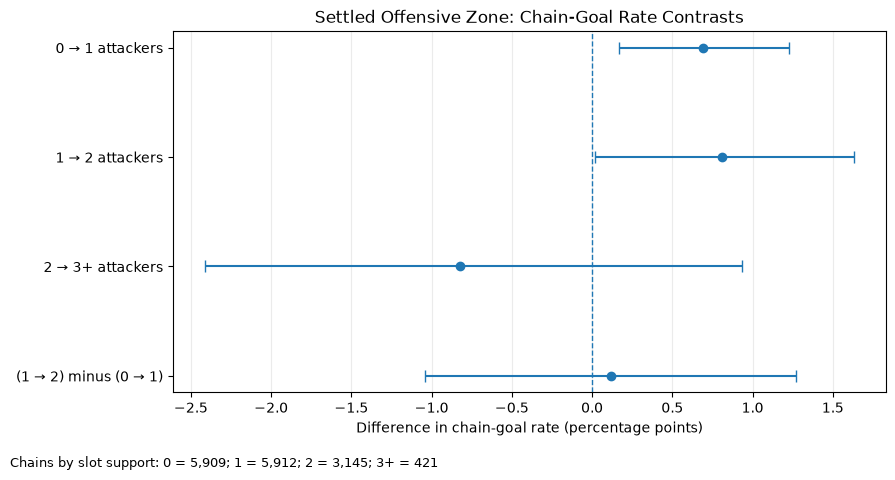

In [24]:
# Plot and export the settled offensive-zone bootstrap contrast figure

settled_bootstrap_figure_path = (
    figure_export_dir
    / "settled_offensive_zone_bootstrap_goal_rate_contrasts.png"
)

_ = plot_bootstrap_contrast_figure(
    context_df=contrast_plot_df,
    descriptive_rates=descriptive_goal_rates,
    context_key="settled_offensive_zone_proxy",
    context_title=(
        "Settled Offensive Zone: "
        "Chain-Goal Rate Contrasts"
    ),
    output_path=settled_bootstrap_figure_path,
)


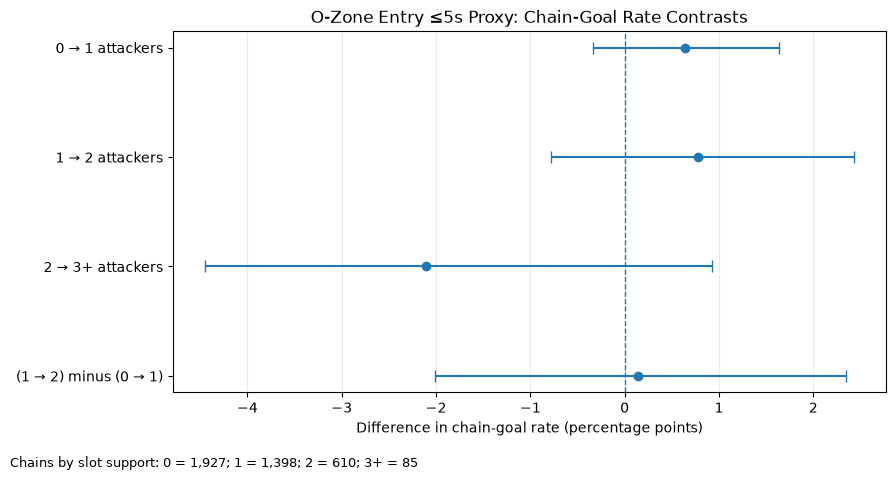

In [25]:
# Plot and export the offensive-zone entry bootstrap contrast figure

entry_bootstrap_figure_path = (
    figure_export_dir
    / "oz_entry_bootstrap_goal_rate_contrasts.png"
)

_ = plot_bootstrap_contrast_figure(
    context_df=contrast_plot_df,
    descriptive_rates=descriptive_goal_rates,
    context_key="oz_entry_5s_proxy",
    context_title=(
        "O-Zone Entry ≤5s Proxy: "
        "Chain-Goal Rate Contrasts"
    ),
    output_path=entry_bootstrap_figure_path,
)


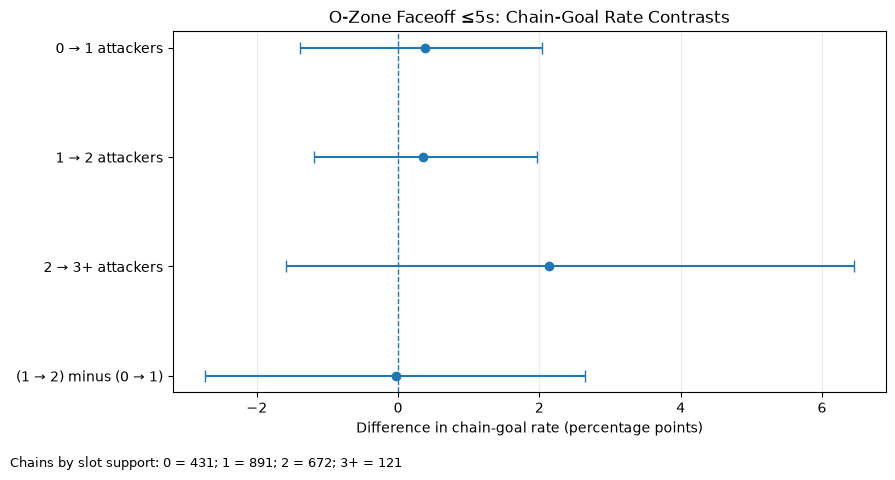

In [26]:
# Plot and export the offensive-zone faceoff bootstrap contrast figure

faceoff_bootstrap_figure_path = (
    figure_export_dir
    / "oz_faceoff_bootstrap_goal_rate_contrasts.png"
)

_ = plot_bootstrap_contrast_figure(
    context_df=contrast_plot_df,
    descriptive_rates=descriptive_goal_rates,
    context_key="oz_faceoff_5s",
    context_title=(
        "O-Zone Faceoff ≤5s: "
        "Chain-Goal Rate Contrasts"
    ),
    output_path=faceoff_bootstrap_figure_path,
)


In [27]:
# Build a compact manifest to verify the context-specific figure exports

bootstrap_figure_manifest = pd.DataFrame(
    [
        {
            "context": "settled_offensive_zone_proxy",
            "figure_type": "bootstrap_contrast",
            "filename": settled_bootstrap_figure_path.name,
            "exists": settled_bootstrap_figure_path.exists(),
            "size_bytes": settled_bootstrap_figure_path.stat().st_size if settled_bootstrap_figure_path.exists() else 0,
        },
        {
            "context": "oz_entry_5s_proxy",
            "figure_type": "bootstrap_contrast",
            "filename": entry_bootstrap_figure_path.name,
            "exists": entry_bootstrap_figure_path.exists(),
            "size_bytes": entry_bootstrap_figure_path.stat().st_size if entry_bootstrap_figure_path.exists() else 0,
        },
        {
            "context": "oz_faceoff_5s",
            "figure_type": "bootstrap_contrast",
            "filename": faceoff_bootstrap_figure_path.name,
            "exists": faceoff_bootstrap_figure_path.exists(),
            "size_bytes": faceoff_bootstrap_figure_path.stat().st_size if faceoff_bootstrap_figure_path.exists() else 0,
        },
    ]
)

bootstrap_figure_manifest

,context,figure_type,filename,exists,size_bytes
0,settled_offensive_zone_proxy,bootstrap_contrast,settled_offensive_zone_bootstrap_goal_rate_con...,True,101720
1,oz_entry_5s_proxy,bootstrap_contrast,oz_entry_bootstrap_goal_rate_contrasts.png,True,99277
2,oz_faceoff_5s,bootstrap_contrast,oz_faceoff_bootstrap_goal_rate_contrasts.png,True,96910


In [28]:
# Validate that all context-specific bootstrap figures were exported successfully

bootstrap_figure_export_validation = {
    "figure_rows": int(len(bootstrap_figure_manifest)),
    "all_figures_exist": bool(bootstrap_figure_manifest["exists"].all()),
    "all_figures_non_empty": bool((bootstrap_figure_manifest["size_bytes"] > 0).all()),
}

bootstrap_figure_export_validation

{'figure_rows': 3, 'all_figures_exist': True, 'all_figures_non_empty': True}

## 9. Conclusions

The statistical analysis supports four conclusions.

First, observed slot support is positively associated with outside-shot chain-goal probability in settled offensive-zone play. Moving from zero to one observed attacking skater in the slot was associated with a 0.69-percentage-point increase in chain-goal rate, while moving from one to two was associated with a further 0.81-point increase. Both game-cluster bootstrap intervals narrowly excluded zero.

Second, the data do not support a distinct threshold at two attackers. The one-to-two increase was only 0.12 percentage points larger than the zero-to-one increase, and the confidence interval for that difference spanned zero. The settled-offense pattern is therefore better described as a progressive increase through two attackers than as a uniquely large second-attacker effect.

Third, the observed settled-offense decline from two to three-or-more attackers remains directional rather than conclusive. The estimated decline was 0.82 percentage points, and most bootstrap estimates were negative, but the 95% interval crossed zero. This does not establish an overload effect.

Fourth, the entry and faceoff contexts did not produce statistically resolved support contrasts. Their point estimates differ in direction, particularly within the smaller three-or-more groups, but the intervals are too wide to support strong context-specific tactical conclusions.

Together with the prior controlled analysis, the evidence supports a cautious hockey interpretation: additional slot support is associated with greater downstream value for settled outside shots through two observed attackers, but the available data do not establish a sharp two-player threshold or a causal penalty for three-or-more attackers.

These findings are observational. Slot occupancy may reflect offensive quality, defensive structure, shot selection, player deployment, and other unmeasured conditions. The estimates should guide further tactical investigation rather than prescribe individual shot decisions.

## 10. Final Validation and Export

Validate the final analytical objects and export the paper-facing statistical tables.

Processed chain-level data remain outside version control. The exported summary tables and figures contain only aggregate results.


In [29]:
# Validate the final statistical outputs

final_validation = {
    "cohort_rows": len(cohort),
    "unique_chain_ids": cohort["chain_id"].nunique(),
    "unique_games": cohort["game_id"].nunique(),
    "chain_goals": int(cohort["chain_goal"].sum()),
    "named_context_chains": int(
        game_context_support["chains"].sum()
    ),
    "named_context_goals": int(
        game_context_support["goals"].sum()
    ),
    "expected_contrast_rows": (
        len(analysis_contexts) * 4
    ),
    "actual_contrast_rows": len(
        bootstrap_contrast_table
    ),
    "all_bootstrap_samples_valid": bool(
        bootstrap_contrast_summary[
            "valid_bootstrap_samples"
        ].eq(10_000).all()
    ),
    "all_figures_exist": bool(
        bootstrap_figure_manifest["exists"].all()
    ),
    "all_figures_non_empty": bool(
        (
            bootstrap_figure_manifest["size_bytes"]
            > 0
        ).all()
    ),
}

final_validation


{'cohort_rows': 21536,
 'unique_chain_ids': 21536,
 'unique_games': 476,
 'chain_goals': 537,
 'named_context_chains': 21522,
 'named_context_goals': 536,
 'expected_contrast_rows': 12,
 'actual_contrast_rows': 12,
 'all_bootstrap_samples_valid': True,
 'all_figures_exist': True,
 'all_figures_non_empty': True}

In [30]:
# Enforce the expected final notebook outputs

assert final_validation["cohort_rows"] == 21536
assert final_validation["unique_chain_ids"] == 21536
assert final_validation["unique_games"] == 476
assert final_validation["chain_goals"] == 537

assert final_validation["named_context_chains"] == 21522
assert final_validation["named_context_goals"] == 536

assert (
    final_validation["actual_contrast_rows"]
    == final_validation["expected_contrast_rows"]
)

assert final_validation["all_bootstrap_samples_valid"]
assert final_validation["all_figures_exist"]
assert final_validation["all_figures_non_empty"]

print("Final Notebook 12 validation passed.")


Final Notebook 12 validation passed.


In [31]:
# Export aggregate statistical tables for paper development

REPORTS_TABLES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

REPORTS_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DESCRIPTIVE_EXPORT_PATH = (
    REPORTS_TABLES_DIR
    / "notebook_12_descriptive_goal_rates.csv"
)

CONTRAST_EXPORT_PATH = (
    REPORTS_TABLES_DIR
    / "notebook_12_bootstrap_contrasts.csv"
)

descriptive_goal_rates.to_csv(
    DESCRIPTIVE_EXPORT_PATH,
    index=False,
)

bootstrap_contrast_table.to_csv(
    CONTRAST_EXPORT_PATH,
    index=False,
)

export_summary = {
    "descriptive_table_path": (
        str(DESCRIPTIVE_EXPORT_PATH)
    ),
    "descriptive_table_exists": (
        DESCRIPTIVE_EXPORT_PATH.exists()
    ),
    "contrast_table_path": (
        str(CONTRAST_EXPORT_PATH)
    ),
    "contrast_table_exists": (
        CONTRAST_EXPORT_PATH.exists()
    ),
    "settled_figure_path": str(
        settled_bootstrap_figure_path
    ),
    "settled_figure_exists": (
        settled_bootstrap_figure_path.exists()
    ),
    "entry_figure_path": str(
        entry_bootstrap_figure_path
    ),
    "entry_figure_exists": (
        entry_bootstrap_figure_path.exists()
    ),
    "faceoff_figure_path": str(
        faceoff_bootstrap_figure_path
    ),
    "faceoff_figure_exists": (
        faceoff_bootstrap_figure_path.exists()
    ),
}

export_summary


{'descriptive_table_path': 'C:\\Users\\rinal\\hockey-analytics\\outside-shot-value\\reports\\tables\\notebook_12_descriptive_goal_rates.csv',
 'descriptive_table_exists': True,
 'contrast_table_path': 'C:\\Users\\rinal\\hockey-analytics\\outside-shot-value\\reports\\tables\\notebook_12_bootstrap_contrasts.csv',
 'contrast_table_exists': True,
 'settled_figure_path': 'C:\\Users\\rinal\\hockey-analytics\\outside-shot-value\\figures\\settled_offensive_zone_bootstrap_goal_rate_contrasts.png',
 'settled_figure_exists': True,
 'entry_figure_path': 'C:\\Users\\rinal\\hockey-analytics\\outside-shot-value\\figures\\oz_entry_bootstrap_goal_rate_contrasts.png',
 'entry_figure_exists': True,
 'faceoff_figure_path': 'C:\\Users\\rinal\\hockey-analytics\\outside-shot-value\\figures\\oz_faceoff_bootstrap_goal_rate_contrasts.png',
 'faceoff_figure_exists': True}